# Tensor power spectrum from `tensor_ps.ini`

Analog of [Tensor_power_spectrum_transfer.ipynb](Tensor_power_spectrum_transfer.ipynb), driven by the native CLASS binary (no classy).

**Workflow** — edit [tensor_ps.ini](tensor_ps.ini) and run it for the different masses:

| run | `root` | `vf_parameters` / extras |
|---|---|---|
| VFDM m=1e-23 | `output/tensor_ps_m23_` | `vf_parameters = 1.e-23, 1.e-16, 1.e-30, 0.01` |
| VFDM m=1e-24 | `output/tensor_ps_m24_` | `vf_parameters = 1.e-24, 1.e-16, 1.e-30, 0.01` |
| VFDM m=1e-25 | `output/tensor_ps_m25_` | `vf_parameters = 1.e-25, 1.e-16, 1.e-30, 0.01` |
| VFDM m=1e-26 | `output/tensor_ps_m26_` | `vf_parameters = 1.e-26, 1.e-16, 1.e-30, 0.01` |
| LCDM (scalar path) | `output/tensor_ps_LCDM_s_` | VFDM block off, `compute_lcdm_tensor = yes` |

The LCDM proper tensor sector (neutrino-damping curve) cannot be written by the native binary — reuse the existing `PS_tensor/*_LCDM_t_transfer.npz` from a previous classy run.

Column layout of `_tk.dat` with VFDM + svt_coupling: `1:k(h/Mpc) ... 7:h_+ 8:dh_+`.

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

# ---- Planck 2018 ----
h_planck = 0.6688
As       = 2.092e-9
ns       = 0.962
r_tensor = 0.036

# ---- Scales / conversions ----
MpctoHzfactor  = 9.7e-15
factoreVtoMpc  = 1.56e29
kj26, kj25, kj24 = 0.0594, 0.184, 0.581

gamma_Ak = np.pi/2

colors = ["#6d5a7a", "#365071", "#b66576", "#ebac8b", "#8a9a7b"]

def Omega_GW(k, h_dot):
    c_light = 3e5
    H0 = 67/c_light
    kp = 0.05
    return (2*np.pi)**3 * As * (k/kp)**(ns-1) * h_dot**2 / (48*np.pi**3 * H0**2)

def Omega_GW_LCDM(k, h_dot, nt=0., r=r_tensor):
    c_light = 3e5
    H0 = 67/c_light
    kp = 0.05
    return (2*np.pi)**3 * r * As * (k/kp)**(nt) * h_dot**2 / (48*np.pi**3 * H0**2)

def Omega_GW_CMB_inflation(freq):
    """Inflationary GW background (arXiv:2004.11396)."""
    Omega_rad = 9.e-5
    f_eq  = 2.27e-18 * 0.31 / np.sqrt(Omega_rad)
    f_cmb = 0.05 * MpctoHzfactor / (2*np.pi)
    nt = -r_tensor/8.
    Omega_CMB_amp = 3./128. * r_tensor * As * Omega_rad
    return Omega_CMB_amp * (freq/f_cmb)**nt * (0.5*(f_eq/freq)**2 + 16./9.)

f_CMB     = np.logspace(-18, -1, 400)
Omega_CMB = Omega_GW_CMB_inflation(f_CMB)

# --- load a _tk.dat file produced by tensor_ps.ini ---
# Column indices (0-based): 0 = k [h/Mpc], 6 = h_+, 7 = dh_+
COL_K, COL_HPLUS, COL_DHPLUS = 0, 6, 7

In [9]:
def load_tk(root_prefix):
    """Load output/<root_prefix>_00_tk.dat. Returns (k_1overMpc, h_plus, dh_plus)."""
    path = f'../../output/{root_prefix}00_tk.dat'
    data = np.loadtxt(path, usecols=(COL_K, COL_HPLUS, COL_DHPLUS))
    k_hMpc  = data[:, 0]
    k       = k_hMpc * h_planck       # convert to 1/Mpc
    h_plus  = data[:, 1]
    dh_plus = data[:, 2]
    return k, h_plus, dh_plus

# VFDM runs
k_24, h_24, dh_24 = load_tk('tensor_ps_m24_')
k_25, h_25, dh_25 = load_tk('tensor_ps_m25_BIS')
k_26, h_26, dh_26 = load_tk('tensor_ps_m26_')

# LCDM scalar-path
k_lcdm_s, h_lcdm_s_raw, dh_lcdm_s = load_tk('tensor_ps_LCDM_s_')

# LCDM proper tensor sector (reuse classy-era npz)
#_f_h  = np.load('../../PS_tensor/h+_LCDM_t_transfer.npz')
#_f_dh = np.load('../../PS_tensor/dh+_LCDM_t_transfer.npz')
#k_lcdm_t, h_lcdm_t, dh_lcdm_t = _f_h['k'], _f_h['h'], _f_dh['hdot']

# Ω_GW per run
Omega_lcdm_s = Omega_GW_LCDM(k_lcdm_s, dh_lcdm_s)
#Omega_lcdm_t = Omega_GW_LCDM(k_lcdm_t, dh_lcdm_t)
Omega_24 = Omega_GW(k_24, dh_24)
Omega_25 = Omega_GW(k_25, dh_25)
Omega_26 = Omega_GW(k_26, dh_26)

f_lcdm_s = MpctoHzfactor * k_lcdm_s
#f_lcdm_t = MpctoHzfactor * k_lcdm_t
f_24, f_25, f_26 = (MpctoHzfactor * k_24, MpctoHzfactor * k_25, MpctoHzfactor * k_26)

## $\Omega_{\mathrm{GW}} h^2$ per mass

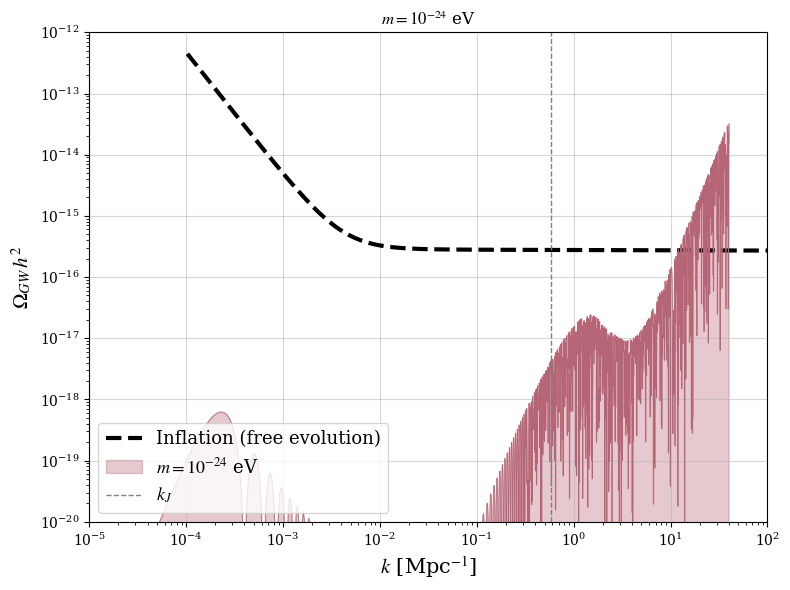

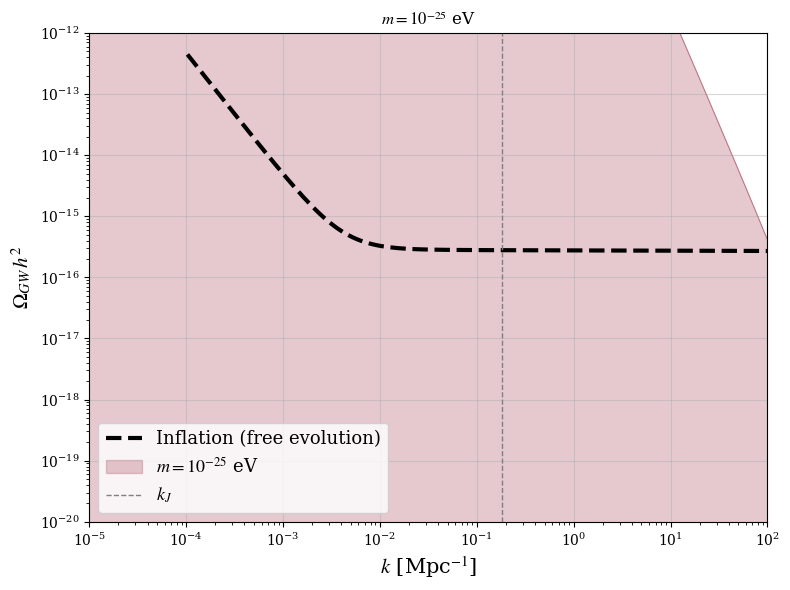

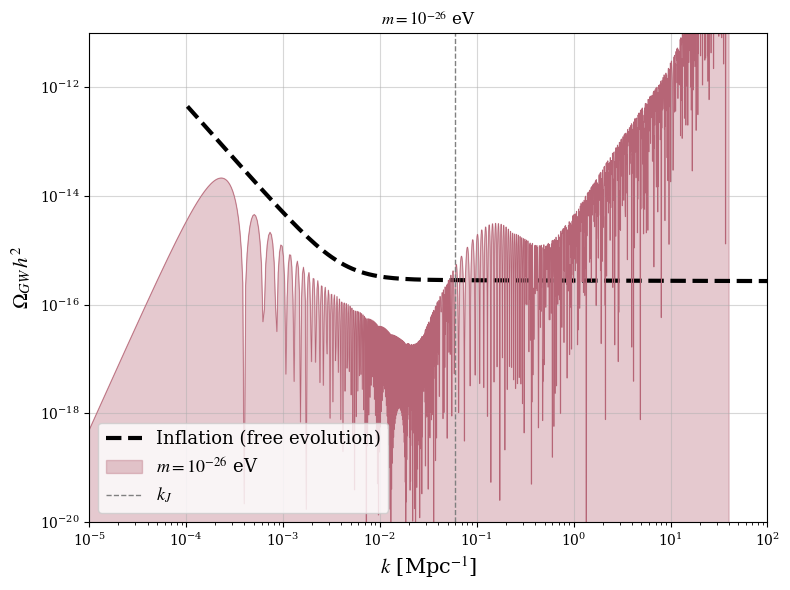

In [10]:
def plot_single_mass(k_m, dh_m, kj, mass_label, ylim=(1e-20, 1e-12)):
    plt.figure(figsize=(8, 6))
    plt.loglog(f_CMB/MpctoHzfactor, Omega_CMB, 'k', ls='--', lw=3, label='Inflation (free evolution)')
    #plt.loglog(k_lcdm_s, Omega_lcdm_s, 'k', ls='--', lw=3, label=r'$\Lambda$CDM (free evolution)')
    #plt.fill_between(k_lcdm_t, Omega_lcdm_t, color='k', alpha=0.8, label=r'$\Lambda$CDM (neutrino damping)')
    plt.fill_between(k_m, Omega_GW(k_m, dh_m), color=colors[2], alpha=0.35, label=mass_label)
    plt.plot(k_m, Omega_GW(k_m, dh_m), color=colors[2], lw=0.5)
    plt.axvline(kj, color='gray', ls='--', lw=1, label=r'$k_J$')
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel(r'$k$ [Mpc$^{-1}$]', size=15)
    plt.ylabel(r'$\Omega_{GW}\, h^2$', size=15)
    plt.title(mass_label)
    plt.legend(loc='lower left', fontsize=13)
    plt.grid(True, alpha=0.5)
    plt.xlim(1e-5, 1e2)
    plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

plot_single_mass(k_24, dh_24, kj24, r'$m=10^{-24}$ eV')
plot_single_mass(k_25, dh_25, kj25, r'$m=10^{-25}$ eV')
plot_single_mass(k_26, dh_26, kj26, r'$m=10^{-26}$ eV', ylim=(1e-20, 1e-11))

## Three masses on one axis

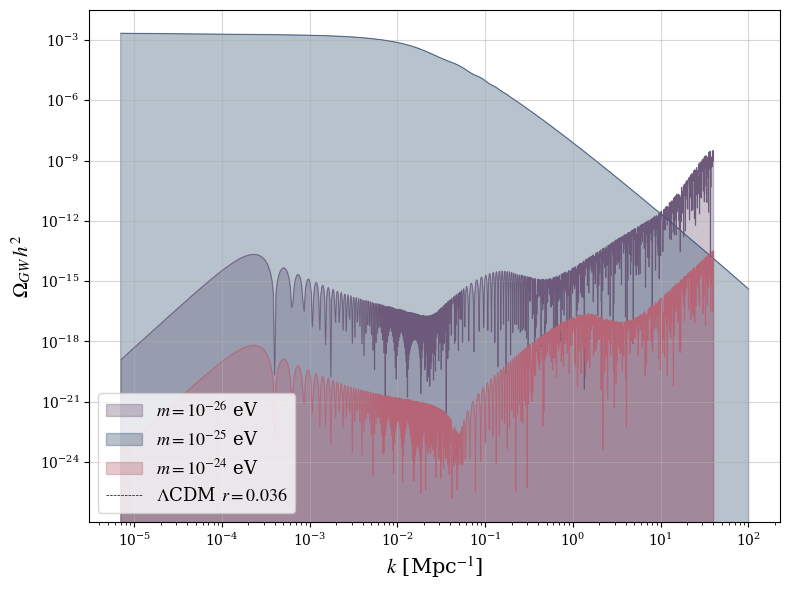

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(k_lcdm_s, Omega_lcdm_s, 'k--', lw=0.5)
for k_m, dh_m, col, lbl in [
    (k_26, dh_26, colors[0], r'$m=10^{-26}$ eV'),
    (k_25, dh_25, colors[1], r'$m=10^{-25}$ eV'),
    (k_24, dh_24, colors[2], r'$m=10^{-24}$ eV'),
]:
    plt.fill_between(k_m, Omega_GW(k_m, dh_m), color=col, alpha=0.35, label=lbl)
    plt.plot(k_m, Omega_GW(k_m, dh_m), color=col, lw=0.5)
plt.plot(k_lcdm_s, Omega_lcdm_s, 'k--', lw=0.5, label=r'$\Lambda$CDM $r=0.036$')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'$k$ [Mpc$^{-1}$]', size=15)
plt.ylabel(r'$\Omega_{GW}\, h^2$', size=15)
plt.legend(loc='lower left', fontsize=13)
plt.grid(True, alpha=0.5)
#plt.ylim(1e-20, 1e-11)
plt.tight_layout()
plt.show()

## Detector overlay

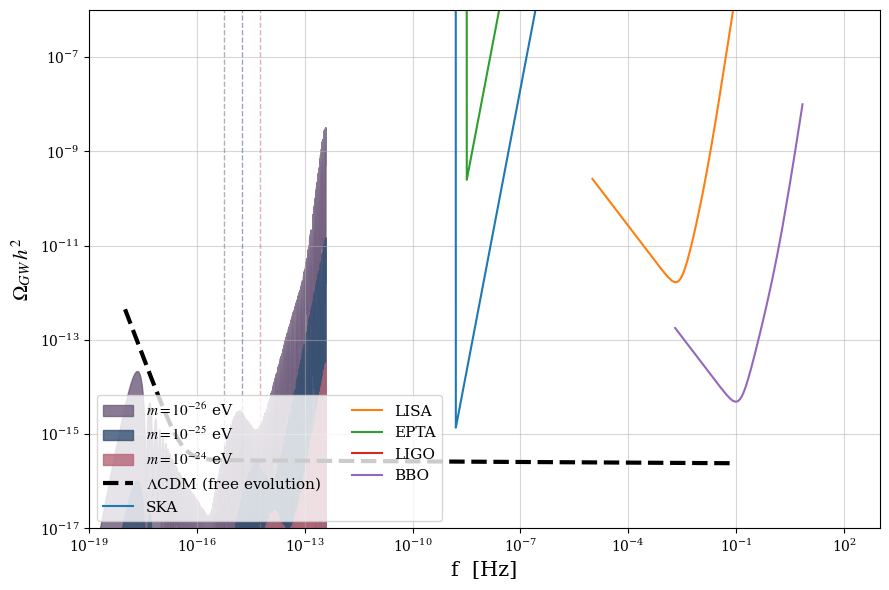

In [5]:
def load_detector(name):
    with open(f'../../detectors/{name}.json', 'r') as fh:
        return np.array(json.load(fh)['data'])

def Omega_GW_detector(freq, hc):
    H0 = 2.27e-18
    return 2/3. * np.pi**2 * hc**2 * freq**2 / H0**2 / 0.67**2

plt.figure(figsize=(9, 6))
for f_arr, Omega_tot, col, lbl, kj in [
    (f_26, Omega_26, colors[0], r'$m=10^{-26}$ eV', kj26),
    (f_25, Omega_25, colors[1], r'$m=10^{-25}$ eV', kj25),
    (f_24, Omega_24, colors[2], r'$m=10^{-24}$ eV', kj24),
]:
    plt.fill_between(f_arr, Omega_tot, color=col, alpha=0.8, label=lbl)
    plt.axvline(MpctoHzfactor*kj, color=col, ls='--', lw=1, alpha=0.5)

plt.loglog(f_CMB, Omega_CMB, 'k', ls='--', lw=3, label=r'$\Lambda$CDM (free evolution)')
#plt.fill_between(f_lcdm_t, Omega_lcdm_t, color='k', alpha=0.8, label=r'$\Lambda$CDM (neutrino damping)')

for name in ['SKA', 'LISA', 'EPTA', 'LIGO', 'BBO']:
    try:
        arr = load_detector(name)
        plt.loglog(arr[:, 0], Omega_GW_detector(arr[:, 0], arr[:, 1]), lw=1.5, label=name)
    except FileNotFoundError:
        pass

plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'f  [Hz]', size=15)
plt.ylabel(r'$\Omega_{GW}\, h^2$', size=15)
plt.legend(loc='lower left', fontsize=11, ncol=2)
plt.grid(True, alpha=0.5)
plt.ylim(1e-17, 1e-6)
plt.xlim(1e-19, 1e3)
plt.tight_layout()
plt.show()

## Precision comparison — $m=10^{-25}$ eV at tol $=10^{-6}$ vs $10^{-8}$

Rerun [tensor_ps.ini](tensor_ps.ini) for m=-25 with `tol_perturbations_integration = 1e-8` and `root = output/tensor_ps_m25_prec_-8_`. The `prec_-6` curve is already loaded as `k_25, dh_25`.

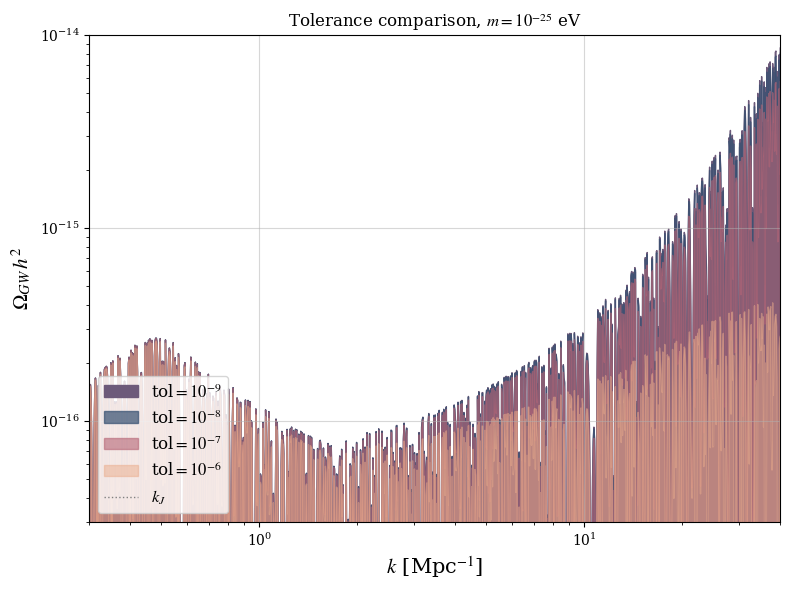

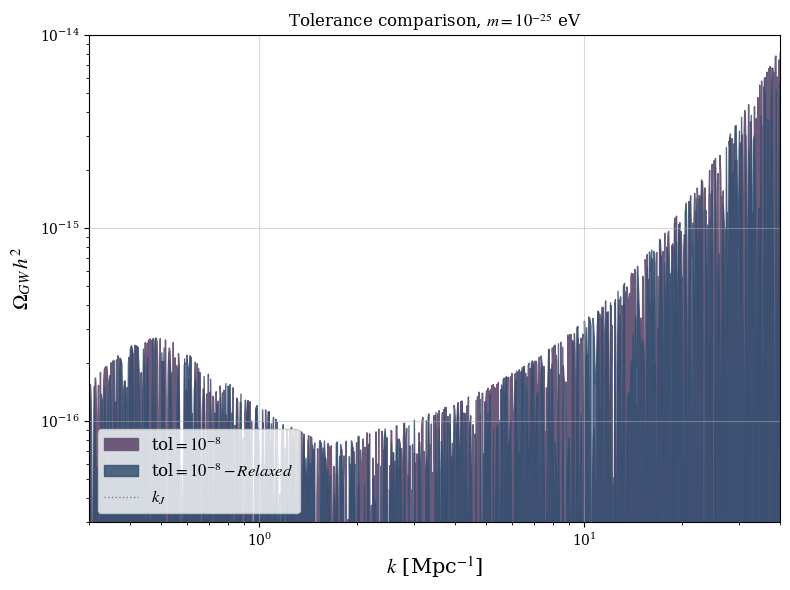

In [ ]:
# Load m=1e-25 at three precisions and overlay
def load_tk_path(path):
    data = np.loadtxt(path, usecols=(COL_K, COL_HPLUS, COL_DHPLUS))
    return data[:, 0] * h_planck, data[:, 1], data[:, 2]

k_25_p6, h_25_p6, dh_25_p6 = load_tk_path('../../output/precision_test_1e25/tensor_ps_m25_prec_-6_00_tk.dat')
k_25_p8, h_25_p8, dh_25_p8 = load_tk_path('../../output/precision_test_1e25/tensor_ps_m25_prec_-8_00_tk.dat')
k_25_p9, h_25_p9, dh_25_p9 = load_tk_path('../../output/precision_test_1e25/tensor_ps_m25_prec_-9_00_tk.dat')
k_25_p7, h_25_p7, dh_25_p7 = load_tk_path('../../output/precision_test_1e25/tensor_ps_m25_prec_-7_00_tk.dat')
k_25_relxed, h_25_relaxed, dh_25_relaxed = load_tk_path('../../output/precision_test_1e25/tensor_ps_m25_00_tk.dat')

Omega_25_p6 = Omega_GW(k_25_p6, dh_25_p6)
Omega_25_p7 = Omega_GW(k_25_p7, dh_25_p7)
Omega_25_p8 = Omega_GW(k_25_p8, dh_25_p8)
Omega_25_p9 = Omega_GW(k_25_p9, dh_25_p9)
Omega_25_relaxed = Omega_GW(k_25_relxed, dh_25_relaxed)

plt.figure(figsize=(8, 6))
plt.fill_between(k_25_p9, Omega_25_p9, color=colors[0],   label=r'tol$=10^{-9}$')
plt.fill_between(k_25_p8, Omega_25_p8, color=colors[1],   label=r'tol$=10^{-8}$', alpha=0.7)
plt.fill_between(k_25_p7, Omega_25_p7, color=colors[2],   label=r'tol$=10^{-7}$', alpha=0.6)
plt.fill_between(k_25_p6, Omega_25_p6, color=colors[3],   label=r'tol$=10^{-6}$', alpha=0.5)
plt.axvline(kj25, color='gray', ls=':', lw=1, label=r'$k_J$')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'$k$ [Mpc$^{-1}$]', size=15)
plt.ylabel(r'$\Omega_{GW}\, h^2$', size=15)
plt.title(r'Tolerance comparison, $m=10^{-25}$ eV')
plt.legend(loc='lower left', fontsize=12)
plt.grid(True, alpha=0.5)
plt.xlim(3e-1, 4e1)
plt.ylim(3e-17, 1e-14)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
plt.fill_between(k_25_p8, Omega_25_p8, color=colors[0],   label=r'tol$=10^{-8}$')
plt.fill_between(k_25_relxed, Omega_25_relaxed, color=colors[1],   label=r'tol$=10^{-8} - Relaxed$', alpha=0.85)
plt.axvline(kj25, color='gray', ls=':', lw=1, label=r'$k_J$')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'$k$ [Mpc$^{-1}$]', size=15)
plt.ylabel(r'$\Omega_{GW}\, h^2$', size=15)
plt.title(r'Tolerance comparison, $m=10^{-25}$ eV')
plt.legend(loc='lower left', fontsize=12)
plt.grid(True, alpha=0.5)
plt.xlim(3e-1, 4e1)
plt.ylim(3e-17, 1e-14)
plt.tight_layout()
plt.show()